In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.colors as mcolors
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

In [2]:
dataset_path = 'Datasets/Dataset_BA1B.xlsx'

df = pd.read_excel(dataset_path)
# df.dropna(inplace=True)
# df['TOP_DEPTH'].fillna(method='ffill', inplace=True)
[c for c in df.columns]
geology_columns = ['UNIT_TYPE_Dunite',
 'UNIT_TYPE_Fault rock',
 'UNIT_TYPE_Gabbro',
 'UNIT_TYPE_Harzburgite',
 'UNIT_TYPE_Metagabbro',
 'UNIT_TYPE_Other',
'TOP_DEPTH'
 # 'UNIT_CLASS_OPHIO',
 # 'UNIT_CLASS_UND',
                  ]
df.dropna(subset='TOP_DEPTH', inplace=True)
# df.drop_duplicates(subset='TOP_DEPTH', inplace=True)
df.sort_values(by='TOP_DEPTH', inplace=True)

In [3]:
[c for c in df.columns]

columns_dont_use = ['CORE',
 'SECTION',
 'IMAGES',
 'SEGMENTATION',
 'TOP_DEPTH',
 'ALTERATION',
 'REMARKS1',
 'REMARKS2',
 'REMARKS4',
 'REMARKS5',
 'Alteration_dummies_50%-90%',
'Alteration_dummies_>90%',
'SECTION_UNIT']

In [4]:
xvars = [
    # 'CORE',
 # 'SECTION',
 'Cell abundance (cells/g)',
 'Mean dry electrical Resistivity (ohmm)',
 # 'Bulk density (g/cm³)',
 'AMS bulk susceptibility',
 'LOI wt%',
 'CO2 wt%',
 'H20 wt%',
 'CaCO3 calc',
 # 'SECTION_UNIT',
 '% of fractures',
 # 'IMAGES',
 # 'SEGMENTATION',
 # 'TOP_DEPTH',
 # 'ALTERATION',
 # 'REMARKS1',
 # 'REMARKS2',
 # 'REMARKS4',
 # 'REMARKS5',
 'PnS2_sum',
 'PnL_sum',
 'PnP3V_sum',
 'PnP3H_sum',
 'PnP4_sum',
 'PnP6V_sum',
 'FnS2_sum',
 'FnL_sum',
 'FnP3V_sum',
 'FnP3H_sum',
 'FnP4_sum',
 'FnP6V_sum',
 'UNIT_TYPE_Dunite',
 'UNIT_TYPE_Fault rock',
 'UNIT_TYPE_Gabbro',
 'UNIT_TYPE_Harzburgite',
 'UNIT_TYPE_Metagabbro',
 'UNIT_TYPE_Other',
 'UNIT_CLASS_OPHIO',
 'UNIT_CLASS_UND',
 'TEXTURES_Brecciated',
 'TEXTURES_Sheared',
 'GRAINSIZE_Cryptocrystalline',
 'GRAINSIZE_Fine grained',
 'GRAINSIZE_Medium grained',
 'GRAINSIZE_Microcrystalline',
 'GRAINSIZE2_Coarse grained',
 'GRAINSIZE2_Cryptocrystalline',
 'GRAINSIZE2_Fine grained',
 'GRAINSIZE2_Medium grained',
 'GRAINSIZE2_Pegmatitic',
 # 'Alteration_dummies_50%-90%',
 # 'Alteration_dummies_>90%',
 'Veins',
 'Serpentine vein',
 'Oxidation',
 'Carbonate veins',
 'Network',
 'Dyke',
 'Black serpentinization',
 'White veins',
 'Open cracks',
 'Dunite',
 'Gabbro',
 'Microgabbro',
 'Green veins',
 'Open crack',
 'Irregular',
 'Waxy green',
 'Alteration',
 'Subvertical',
 'Fine grained',
 'Subhorizontal',
 'Lineation',
 'Magnetite',
 'Thickness',
 'Harzburgite',
 'Altered gabbro',
 'Offset',
 'Altered',
 'Crack',
 'Pxenites',
 'Microbio sample',
 'Bulk serp',
 'Bulk',
 'Coalescence',
 'Waxy',
 'Wavy',
 'Slickensides',
 'Alteration halo',
 'Plagioclase',
 'Fracture',
 'Sheared',
 'Pyroxenite',
 'Striations',
 'Branching',
 'Blue patches',
 'Magmatic intrusions',
 'Hydrothermal',
 'Rodingite',
 'Magmatic veins',
 'Offsets',
 'Shearing',
 'Dark green',
 'Dunitic zone',
 'SiO2',
 'TiO2',
 'Al2O3',
 'Fe2O3t',
 'MnO',
 'MgO',
 'CaO',
 'Na2O',
 'K2O',
 'P2O5',
 '100*Fe(III)/FeT',
 'Vrecal',
 'Crrecal',
 'Co',
 'Nirecal',
 'Curecal',
 'Znrecal',
 'Srrecal',
 'Redness',
 'Greenness',
 'Blueness',
 'Y (luminance)']

In [24]:
def meow_reg(df, X_cols, Y_col):
    from catboost import CatBoostRegressor, Pool
    from sklearn.metrics import mean_squared_error, r2_score

    X = df[X_cols]
    y = df[Y_col]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_pool = Pool(X_train, y_train)
    eval_pool = Pool(X_test, y_test)
    
    # Instantiate the CatBoost regressor
    catboost_reg = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=2, loss_function='RMSE')
    
    # Fit the model to the training data
    catboost_reg.fit(X_train, y_train, eval_set=eval_pool, verbose=100, early_stopping_rounds=10)
    
    # Predict on the test data
    y_pred = catboost_reg.predict(X_test)
    
    # Calculate the Mean Squared Error
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error:", mse)
    print('r2 score:', r2_score(y_test, y_pred))
    print('\n')
    return catboost_reg

In [25]:
# print('######## PERSON SELECTED ##########\n')
# chemistry_biology = ['Cell abundance (cells/g)','LOI wt%',
#  'CO2 wt%',
#  'H20 wt%',
#  'CaCO3 calc',
# 'SiO2',
#  'TiO2',
#  'Al2O3',
#  'Fe2O3t',
#  'MnO',
#  'MgO',
#  'CaO',
#  'Na2O',
#  'K2O',
#  'P2O5',
#  '100*Fe(III)/FeT',
# ]
# print('---catboost for chemistry and biology---')
# cb = meow_reg(df=df, X_cols=chemistry_biology, Y_col='Bulk density (g/cm³)')

# fractures = ['% of fractures',
#  'PnS2_sum',
#  'PnL_sum',
#  'PnP3V_sum',
#  'PnP3H_sum',
#  'PnP4_sum',
#  'PnP6V_sum',
#  'FnS2_sum',
#  'FnL_sum',
#  'FnP3V_sum',
#  'FnP3H_sum',
#  'FnP4_sum',
#  'FnP6V_sum',]
# # print('---catboost for fractures---')
# frac = meow_reg(df=df, X_cols=fractures, Y_col='Bulk density (g/cm³)')

# geology = ['UNIT_TYPE_Dunite',
#  'UNIT_TYPE_Fault rock',
#  'UNIT_TYPE_Gabbro',
#  'UNIT_TYPE_Harzburgite',
#  'UNIT_TYPE_Metagabbro',
#  'UNIT_TYPE_Other',
#  'UNIT_CLASS_OPHIO',
#  'UNIT_CLASS_UND',
#  'TEXTURES_Brecciated',
#  'TEXTURES_Sheared',
#  'GRAINSIZE_Cryptocrystalline',
#  'GRAINSIZE_Fine grained',
#  'GRAINSIZE_Medium grained',
#  'GRAINSIZE_Microcrystalline',
#  'GRAINSIZE2_Coarse grained',
#  'GRAINSIZE2_Cryptocrystalline',
#  'GRAINSIZE2_Fine grained',
#  'GRAINSIZE2_Medium grained',
#  'GRAINSIZE2_Pegmatitic',]
# print('---catboost for geology---')
# geo = meow_reg(df=df, X_cols=geology, Y_col='Bulk density (g/cm³)')

physics = ['Mean dry electrical Resistivity (ohmm)',
 'AMS bulk susceptibility',]
print('---catboost for physics---')
phys = meow_reg(df=df, X_cols=physics, Y_col='Bulk density (g/cm³)')

# chatgpt = [ 'Veins',
#  'Serpentine vein',
#  'Oxidation',
#  'Carbonate veins',
#  'Network',
#  'Dyke',
#  'Black serpentinization',
#  'White veins',
#  'Open cracks',
#  'Dunite',
#  'Gabbro',
#  'Microgabbro',
#  'Green veins',
#  'Open crack',
#  'Irregular',
#  'Waxy green',
#  'Alteration',
#  'Subvertical',
#  'Fine grained',
#  'Subhorizontal',
#  'Lineation',
#  'Magnetite',
#  'Thickness',
#  'Harzburgite',
#  'Altered gabbro',
#  'Offset',
#  'Altered',
#  'Crack',
#  'Pxenites',
#  'Microbio sample',
#  'Bulk serp',
#  'Bulk',
#  'Coalescence',
#            'Waxy',
#  'Wavy',
#  'Slickensides',
#  'Alteration halo',
#  'Plagioclase',
#  'Fracture',
#  'Sheared',
#  'Pyroxenite',
#  'Striations',
#  'Branching',
#  'Blue patches',
#  'Magmatic intrusions',
#  'Hydrothermal',
#  'Rodingite',
#  'Magmatic veins',
#  'Offsets',
#  'Shearing',
#  'Dark green',
#  'Dunitic zone',]
# print('---catboost for chatgpt---')
# gpt = meow_reg(df=df, X_cols=chatgpt, Y_col='Bulk density (g/cm³)')


# other = ['Vrecal',
#  'Crrecal',
#  'Co',
#  'Nirecal',
#  'Curecal',
#  'Znrecal',
#  'Srrecal',
#  'Redness',
#  'Greenness',
#  'Blueness',
#  'Y (luminance)']
# print('---catboost for other---')
# oth = meow_reg(df=df, X_cols=other, Y_col='Bulk density (g/cm³)')


---catboost for physics---
0:	learn: 0.1299830	test: 0.1215530	best: 0.1215530 (0)	total: 375us	remaining: 375ms
100:	learn: 0.0731613	test: 0.0734999	best: 0.0734999 (100)	total: 14.5ms	remaining: 129ms
200:	learn: 0.0536704	test: 0.0596812	best: 0.0596812 (200)	total: 25.7ms	remaining: 102ms
300:	learn: 0.0439171	test: 0.0532869	best: 0.0532869 (300)	total: 34.8ms	remaining: 80.8ms
400:	learn: 0.0369543	test: 0.0484579	best: 0.0484579 (400)	total: 44.1ms	remaining: 65.9ms
500:	learn: 0.0318173	test: 0.0457866	best: 0.0457866 (499)	total: 52.6ms	remaining: 52.4ms
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.04406113432
bestIteration = 584

Shrink model to first 585 iterations.
Mean Squared Error: 0.001941383915494284
r2 score: 0.8702128220270504




In [26]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score

X = df[physics]
y = df['Bulk density (g/cm³)']

# # Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Instantiate the CatBoost regressor
# catboost_reg = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, loss_function='RMSE')

# # Fit the model to the training data
# catboost_reg.fit(X_train, y_train, verbose=100, early_stopping_rounds=10)

# # Predict on the test data
y_pred = phys.predict(X_test)

# # Calculate the Mean Squared Error
# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error:", mse)
# print('r2 score:', r2_score(y_test, y_pred))

In [159]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict on the training data
y_pred = model.predict(X_train)

# Calculate R² score
r2 = r2_score(y_train, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

# Output the results
print(f"R²: {r2}")
print(f"RMSE: {rmse}")


R²: 0.10300526937942922
RMSE: 0.12458455989809364


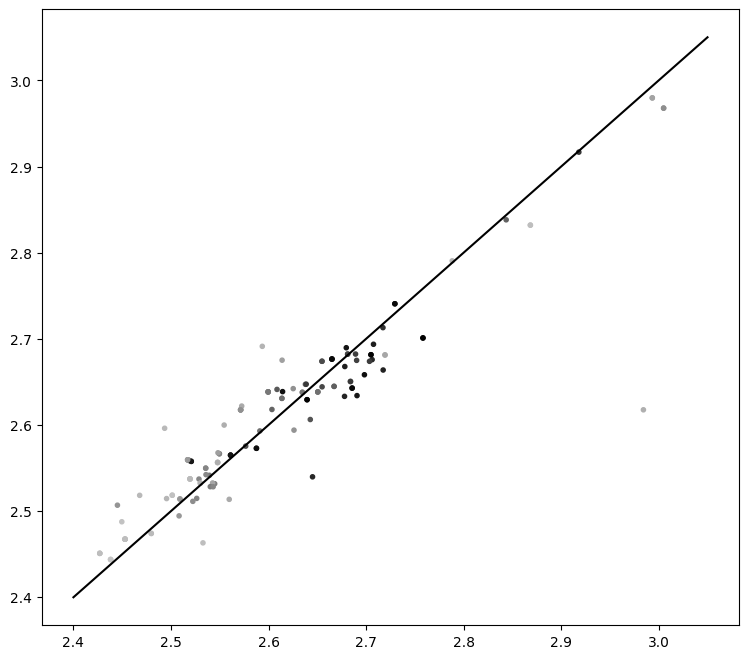

In [42]:
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(y_test, y_pred, c=df['TOP_DEPTH'].loc[y_test.index], cmap='Greys', marker='.', vmin=-200)
# ax.scatter(y_train, catboost_reg.predict(X_train), marker='x', c=df['TOP_DEPTH'].loc[y_train.index])
ax.plot([2.4, 3.05], [2.4, 3.05], color='black')

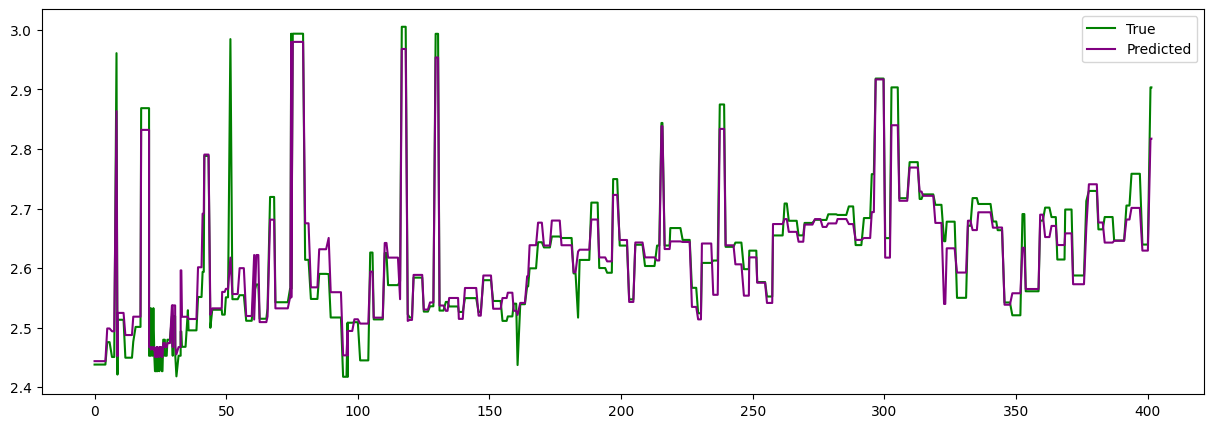

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.TOP_DEPTH, df['Bulk density (g/cm³)'], label='True', color='green')
ax.plot(df.loc[X.index].TOP_DEPTH, phys.predict(X), label='Predicted', color='purple')
ax.legend()

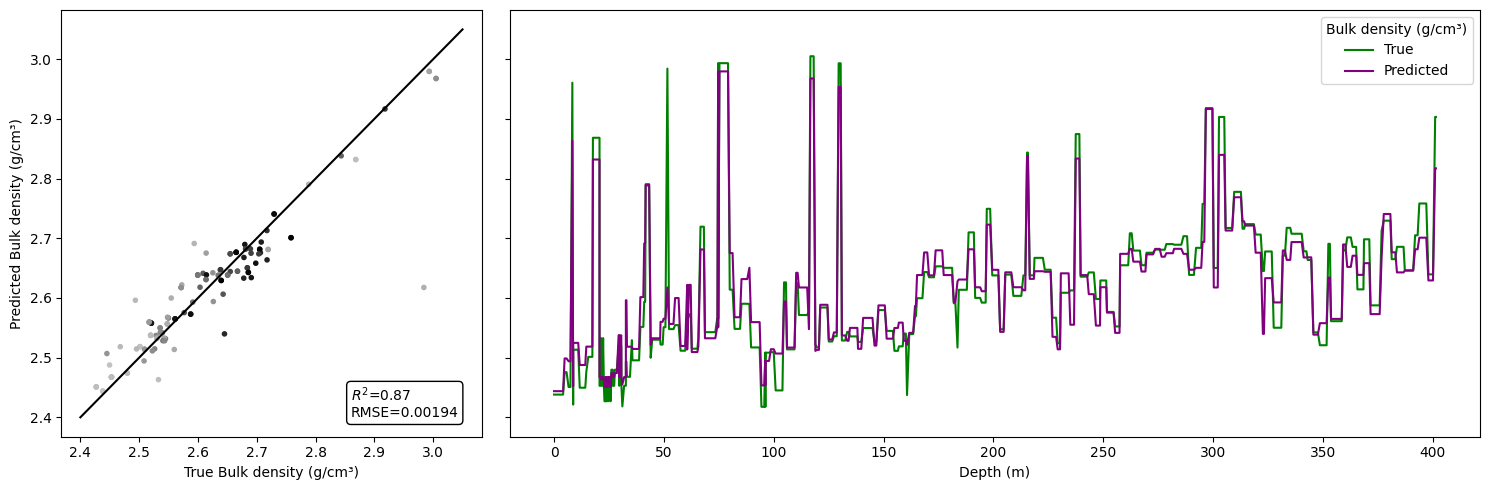

In [67]:
import matplotlib.pyplot as plt

# Create a figure and a grid with specified widths
fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [1.3, 3]}, figsize=(15, 5), sharey=True)

# Plot something in the first subplot
ax1.scatter(y_test, y_pred, c=df['TOP_DEPTH'].loc[y_test.index], cmap='Greys', marker='.', vmin=-200)
# ax.scatter(y_train, catboost_reg.predict(X_train), marker='x', c=df['TOP_DEPTH'].loc[y_train.index])
ax1.plot([2.4, 3.05], [2.4, 3.05], color='black')
ax1.set_ylabel('Predicted Bulk density (g/cm³)')
ax1.set_xlabel('True Bulk density (g/cm³)')
ax1.text(x=2.86., y=2.4, s='$R^2$=0.87'+'\n' + 'RMSE=0.00194', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round'))

# Plot something in the second subplot
ax2.plot(df.TOP_DEPTH, df['Bulk density (g/cm³)'], label='True', color='green')
ax2.plot(df.loc[X.index].TOP_DEPTH, phys.predict(X), label='Predicted', color='purple')
ax2.set_xlabel('Depth (m)')
ax2.legend(title='Bulk density (g/cm³)')

# Adjust layout and show the plot
fig.tight_layout()

In [91]:
physics

['Mean dry electrical Resistivity (ohmm)', 'AMS bulk susceptibility']

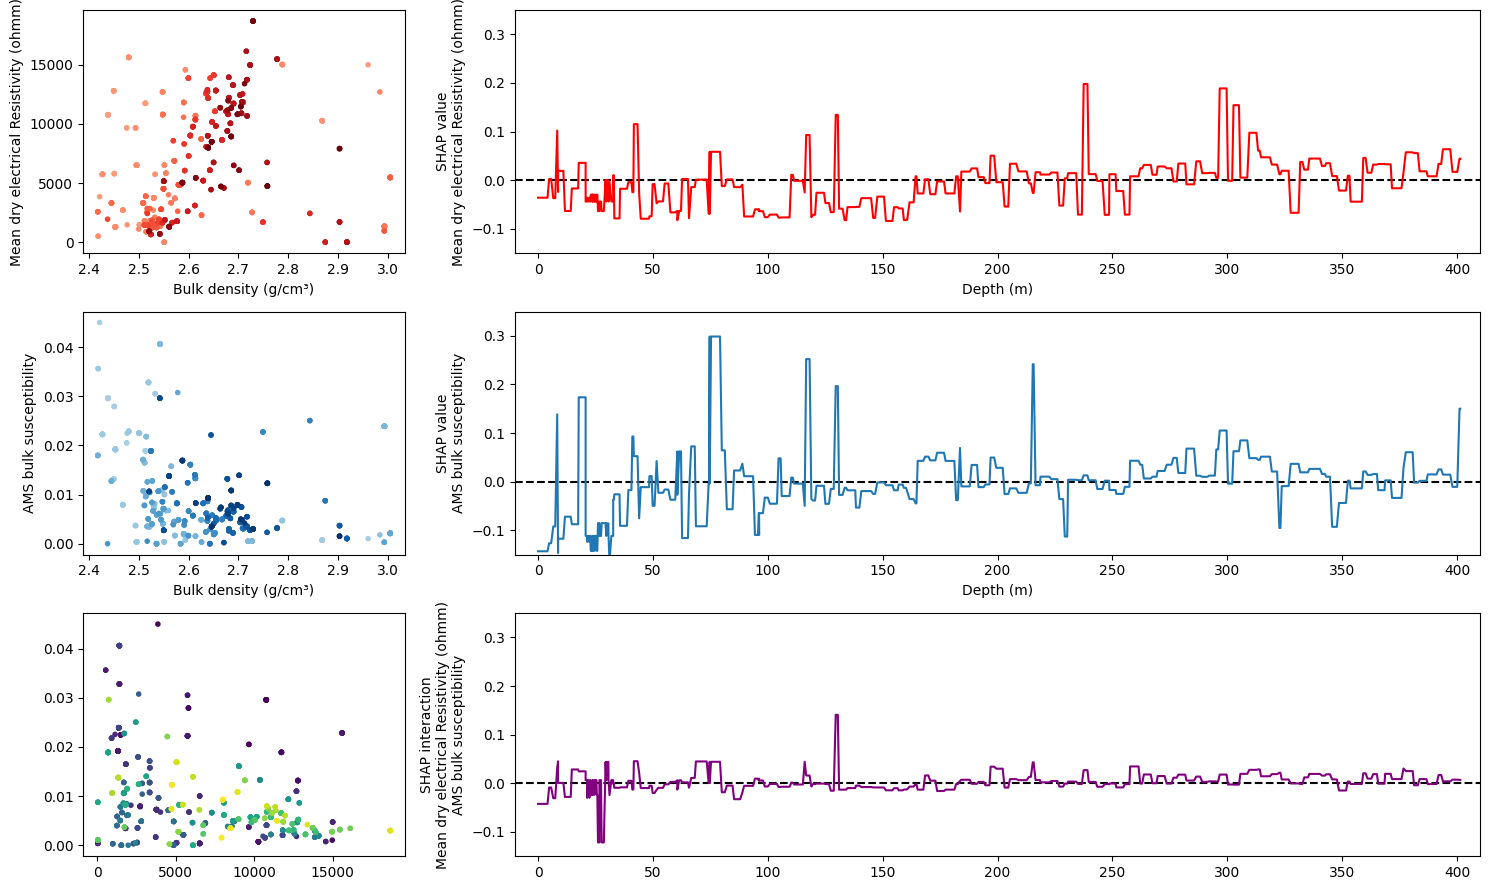

In [158]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 2, gridspec_kw={'width_ratios': [3, 9]}, figsize=(15, 9))

ax1[0].scatter(df['Bulk density (g/cm³)'], df['Mean dry electrical Resistivity (ohmm)'], c=df.TOP_DEPTH, cmap='Reds', vmin=-200, marker='.')
ax1[0].set_ylabel('Mean dry electrical Resistivity (ohmm)')
ax1[0].set_xlabel('Bulk density (g/cm³)')

ax2[0].scatter(df['Bulk density (g/cm³)'], df['AMS bulk susceptibility'], c=df.TOP_DEPTH, cmap='Blues', vmin=-200, marker='.')
ax2[0].set_ylabel('AMS bulk susceptibility')
ax2[0].set_xlabel('Bulk density (g/cm³)')

import shap

explainer = shap.TreeExplainer(phys)
shap_values = explainer(X)
shap_df = pd.DataFrame( columns=X.columns, index=df['TOP_DEPTH'])
for n, c in enumerate(X.columns):
    shap_df[c] = shap_values.values[:,n]

ax1[1].plot(shap_df.index, shap_df['Mean dry electrical Resistivity (ohmm)'], color='red')
ax1[1].set_ylabel('SHAP value\nMean dry electrical Resistivity (ohmm)')
ax1[1].set_ylim(-0.15, 0.35)
ax1[1].plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
ax1[1].set_xlim(-10, 410)
ax1[1].set_xlabel('Depth (m)')

ax2[1].plot(shap_df.index, shap_df['AMS bulk susceptibility'])
ax2[1].set_ylabel('SHAP value\nAMS bulk susceptibility')
ax2[1].set_ylim(-0.15, 0.35)
ax2[1].plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
ax2[1].set_xlim(-10, 410)
ax2[1].set_xlabel('Depth (m)')

# df.plot.scatter('Mean dry electrical Resistivity (ohmm)', 'AMS bulk susceptibility', ax=ax3[0], marker='.', c='TOP_DEPTH')
ax3[0].scatter(df['Mean dry electrical Resistivity (ohmm)'], df['AMS bulk susceptibility'], marker='.', c=df.TOP_DEPTH)
shap_interaction_values = explainer.shap_interaction_values(X)
ax3[1].plot(df.TOP_DEPTH, shap_interaction_values[:,:,1][:,0], color='Purple')
ax3[1].set_ylim(-0.15, 0.35)
ax3[1].plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
ax3[1].set_xlim(-10, 410)
ax3[1].set_ylabel('SHAP interaction\nMean dry electrical Resistivity (ohmm)\nAMS bulk susceptibility')

fig.tight_layout()

<Axes: xlabel='Mean dry electrical Resistivity (ohmm)', ylabel='AMS bulk susceptibility'>

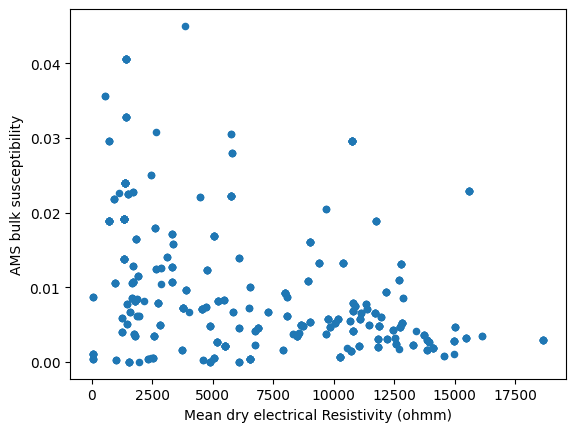

In [149]:
df.plot.scatter('Mean dry electrical Resistivity (ohmm)', 'AMS bulk susceptibility')


In [129]:
shap_interaction_values = explainer.shap_interaction_values(X)

In [138]:
shap_interaction_values[0][0][1]

-0.04226044565773605

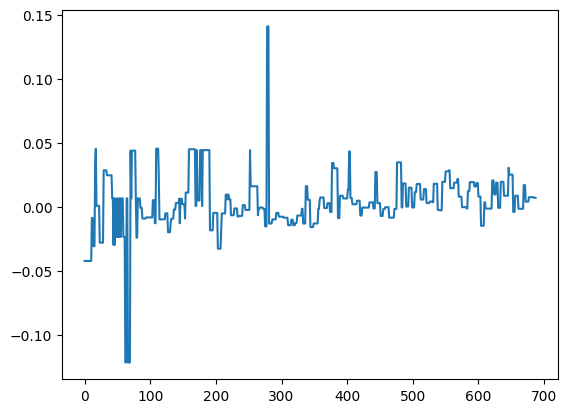

In [143]:
plt.plot(shap_interaction_values[:,:,1][:,0])

<Axes: >

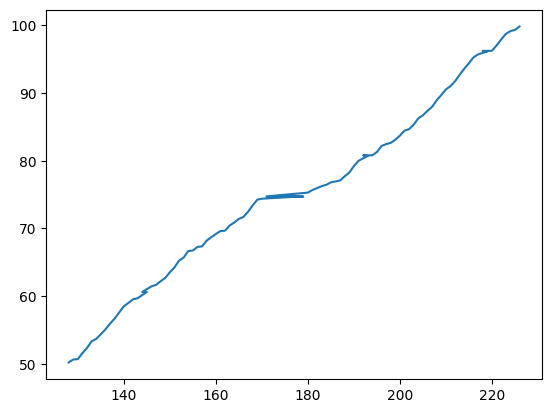

In [12]:
# df[df.TOP_DEPTH.between(50, 100)].TOP_DEPTH.sort_values().plot()

In [13]:
# plt.bar(np.arange(0, catboost_reg.feature_importances_.shape[0], 1), catboost_reg.feature_importances_)

In [14]:
# feature_df = pd.DataFrame({'feature_importance_default':catboost_reg.feature_importances_}, index=X_train.columns)
# feature_df.sort_values('feature_importance_default').plot.bar(figsize=(15, 5))

In [15]:
# !pip install shap

In [68]:
import shap


In [69]:
shap.initjs()


In [70]:
explainer = shap.TreeExplainer(phys)
shap_values = explainer(X)

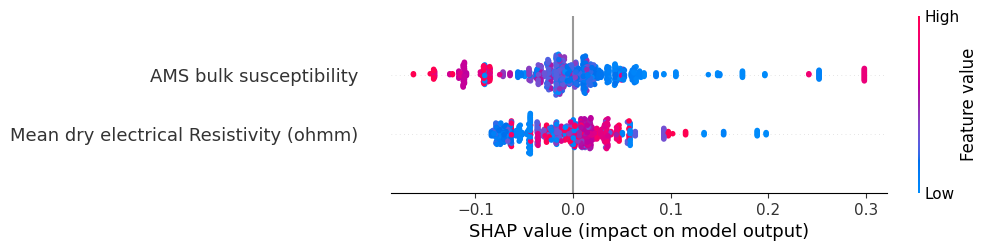

In [71]:
shap.plots.beeswarm(shap_values, max_display=25)


In [72]:
# shap_df = pd.Da taFrame({'shap_value':shap_values.values})#, columns=X.columns, index=df['TOP_DEPTH'])
shap_df = pd.DataFrame( columns=X.columns, index=df['TOP_DEPTH'])
# shap_df.values = shap_values.values
for n, c in enumerate(X.columns):
    shap_df[c] = shap_values.values[:,n]

shap_df

,Mean dry electrical Resistivity (ohmm),AMS bulk susceptibility
TOP_DEPTH,,
0.00,-0.035837,-0.142819
0.50,-0.035837,-0.142819
0.91,-0.035837,-0.142819
1.19,-0.035837,-0.142819
1.60,-0.035837,-0.142819
...,...,...
399.65,0.017279,-0.010420
400.10,0.017279,-0.010420
401.09,0.044381,0.150357


<Axes: xlabel='TOP_DEPTH'>

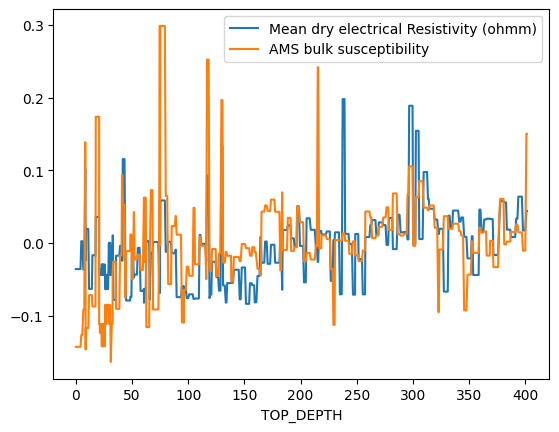

In [75]:
shap_df.plot()

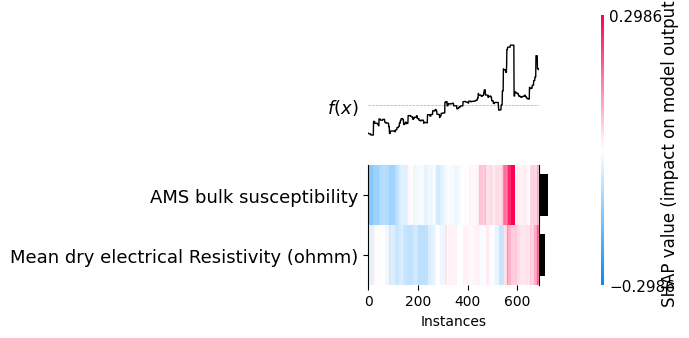

<Axes: xlabel='Instances'>

In [76]:
shap.plots.heatmap(shap_values)

In [80]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [86]:
interaction_matrix

array([[  0.,   1., 100.]])

In [77]:
# import matplotlib.pyplot as pl
# import numpy as np
# import matplotlib as mpl

from shap import Explanation
from shap.utils import OpChain
# from shap.utils import convert_ordering
# from . import colors
# from ._labels import labels
# from shap._utils import convert_ordering

def convert_ordering(ordering, shap_values):
    if issubclass(type(ordering), OpChain):
        ordering = ordering.apply(Explanation(shap_values))
    if issubclass(type(ordering), Explanation):
        if "argsort" in [op["name"] for op in ordering.op_history]:
            ordering = ordering.values
        else:
            ordering = ordering.argsort.flip.values
    return ordering

def heatmap(
    shap_values,
    instance_order=Explanation.hclust(),
    feature_values=Explanation.abs.mean(0),
    feature_order=None,
    max_display=10,
    # cmap=colors.red_white_blue,
    show=True,
    plot_width=8,
    ax=None,
):
    """Create a heatmap plot of a set of SHAP values.

    This plot is designed to show the population substructure of a dataset using supervised
    clustering and a heatmap.
    Supervised clustering involves clustering data points not by their original
    feature values but by their explanations.
    By default, we cluster using :func:`shap.utils.hclust_ordering`,
    but any clustering can be used to order the samples.

    Parameters
    ----------
    shap_values : shap.Explanation
        A multi-row :class:`.Explanation` object that we want to visualize in a
        cluster ordering.

    instance_order : OpChain or numpy.ndarray
        A function that returns a sort ordering given a matrix of SHAP values and an axis, or
        a direct sample ordering given as an ``numpy.ndarray``.

    feature_values : OpChain or numpy.ndarray
        A function that returns a global summary value for each input feature, or an array of such values.

    feature_order : None, OpChain, or numpy.ndarray
        A function that returns a sort ordering given a matrix of SHAP values and an axis, or
        a direct input feature ordering given as an ``numpy.ndarray``.
        If ``None``, then we use ``feature_values.argsort``.

    max_display : int
        The maximum number of features to display (default is 10).

    show : bool
        Whether ``matplotlib.pyplot.show()`` is called before returning.
        Setting this to ``False`` allows the plot
        to be customized further after it has been created.

    plot_width : int, default 8
        The width of the heatmap plot.

    ax : matplotlib Axes
        Axes object to draw the plot onto, otherwise uses the current Axes.

    Returns
    -------
    ax: matplotlib Axes
        Returns the Axes object with the plot drawn onto it.

    Examples
    --------
    See `heatmap plot examples <https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/heatmap.html>`_.

    """
    # sort the SHAP values matrix by rows and columns
    values = shap_values.values
    if issubclass(type(feature_values), OpChain):
        feature_values = feature_values.apply(Explanation(values))
    if issubclass(type(feature_values), Explanation):
        feature_values = feature_values.values
    if feature_order is None:
        feature_order = np.argsort(-feature_values)
    elif issubclass(type(feature_order), OpChain):
        feature_order = feature_order.apply(Explanation(values))
    elif not hasattr(feature_order, "__len__"):
        raise Exception(f"Unsupported feature_order: {str(feature_order)}!")
    # xlabel = "Instances"
    instance_order = convert_ordering(instance_order, shap_values)
    # if issubclass(type(instance_order), OpChain):
    #     #xlabel += " " + instance_order.summary_string("SHAP values")
    #     instance_order = instance_order.apply(Explanation(values))
    # elif not hasattr(instance_order, "__len__"):
    #     raise Exception("Unsupported instance_order: %s!" % str(instance_order))
    # else:
    #     instance_order_ops = None

    feature_names = np.array(shap_values.feature_names)[feature_order]
    values = shap_values.values[instance_order][:, feature_order]
    feature_values = feature_values[feature_order]

    return values, feature_names
    # if we have more features than `max_display`, then group all the excess features
    # into a single feature
    # if values.shape[1] > max_display:
    #     new_values = np.zeros((values.shape[0], max_display))
    #     new_values[:, :-1] = values[:, : max_display - 1]
    #     new_values[:, -1] = values[:, max_display - 1 :].sum(1)
    #     new_feature_values = np.zeros(max_display)
    #     new_feature_values[:-1] = feature_values[: max_display - 1]
    #     new_feature_values[-1] = feature_values[max_display - 1 :].sum()
    #     feature_names = [
    #         *feature_names[: max_display - 1],
    #         f"Sum of {values.shape[1] - max_display + 1} other features",
    #     ]
    #     values = new_values
    #     feature_values = new_feature_values
    #     return values
    # else:
    #     return values

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (2).

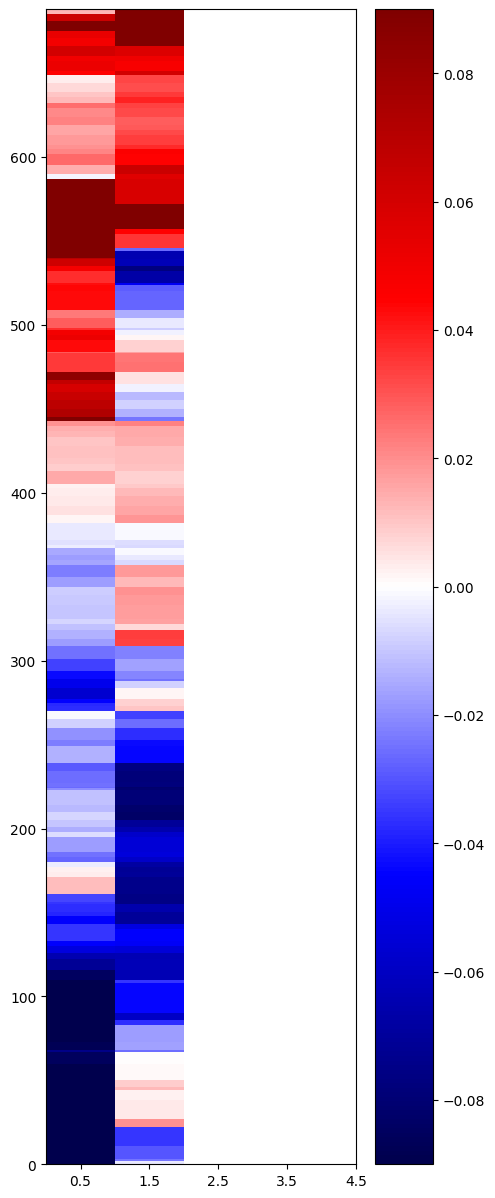

In [78]:
fig, ax = plt.subplots(figsize=(5, 15))
hm, featnames = heatmap(shap_values)
cbar = ax.pcolormesh(hm[:,0:5], cmap='seismic', vmin=-0.09, vmax=0.09)
fig.colorbar(cbar)
ax.set_xticks(np.arange(0, 5, 1)+0.5)
ax.set_xticklabels(featnames[0:5], rotation=90)

In [ ]:
shap_df.plot(legend=False, figsize=(15,5))

In [ ]:
for row in shap_df.iterrows():

    depth = row[0]
    row = row[1]
    
    print(depth, '\t', row.index[row.argmax()], '\t', row.max())
    